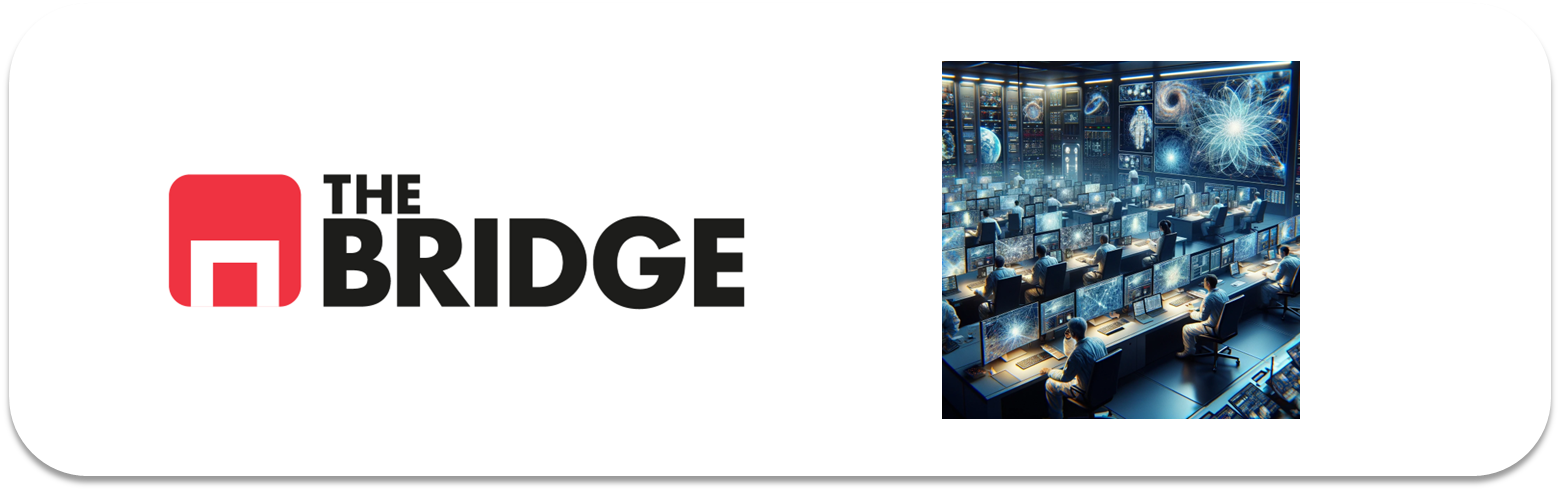

## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import load_img, img_to_array

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras. 



Train samples: 4000
Test samples: 1000
Distribucion train (cat, dog): [2000 2000]
Distribucion test  (cat, dog): [500 500]


/Users/n0xh4ck/ONLINE_DS_THEBRIDGE_RepoEjercicios/venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 159,041 (621.25 KB)

 Trainable params: 159,041 (621.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5397 - loss: 0.6894 - val_accuracy: 0.5475 - val_loss: 0.6815
Epoch 2/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5944 - loss: 0.6607 - val_accuracy: 0.6162 - val_loss: 0.6532
Epoch 3/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6528 - loss: 0.6208 - val_accuracy: 0.6712 - val_loss: 0.6187
Epoch 4/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6794 - loss: 0.6003 - val_accuracy: 0.6750 - val_loss: 0.6089
Epoch 5/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6969 - loss: 0.5787 - val_accuracy: 0.6575 - val_loss: 0.6146
Epoch 6/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7312 - loss: 0.5395 - val_accuracy: 0.6787 - val_loss: 0.6136
Epoch 7/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7638 - loss: 0.4968 - val_accuracy: 0.6625 - val_loss: 0.6519
Epoch 8/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7778 - loss: 0.4678 - val_accuracy: 0.6538 - val_los

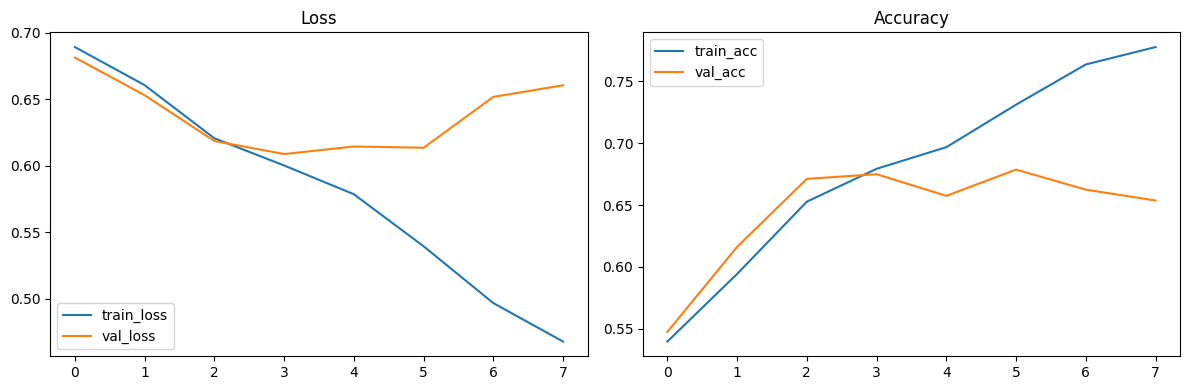

Test Loss: 0.6028
Test Accuracy: 0.6610

Classification report
              precision    recall  f1-score   support

         cat       0.65      0.69      0.67       500
         dog       0.67      0.63      0.65       500

    accuracy                           0.66      1000
   macro avg       0.66      0.66      0.66      1000
weighted avg       0.66      0.66      0.66      1000



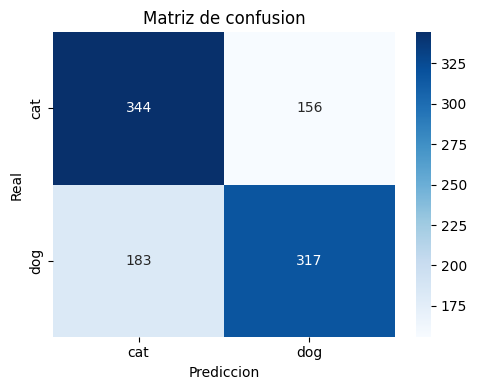


Errores por clase:
true_label
dog    183
cat    156
Name: count, dtype: int64

Seleccion final (top 10% por clase real):
          filename true_label pred_label  wrong_confidence
337  cat.11793.jpg        cat        dog          0.926293
368  cat.11899.jpg        cat        dog          0.920639
382  cat.11952.jpg        cat        dog          0.897899
153  cat.11168.jpg        cat        dog          0.877080
893   dog.9530.jpg        dog        cat          0.859056
97   cat.10992.jpg        cat        dog          0.853678
566   dog.8327.jpg        dog        cat          0.847050
308  cat.11711.jpg        cat        dog          0.846100
834   dog.9276.jpg        dog        cat          0.841878
273  cat.11599.jpg        cat        dog          0.822001
740   dog.8958.jpg        dog        cat          0.818714
8    cat.10728.jpg        cat        dog          0.814825
918   dog.9609.jpg        dog        cat          0.812731
20   cat.10755.jpg        cat        dog          0.

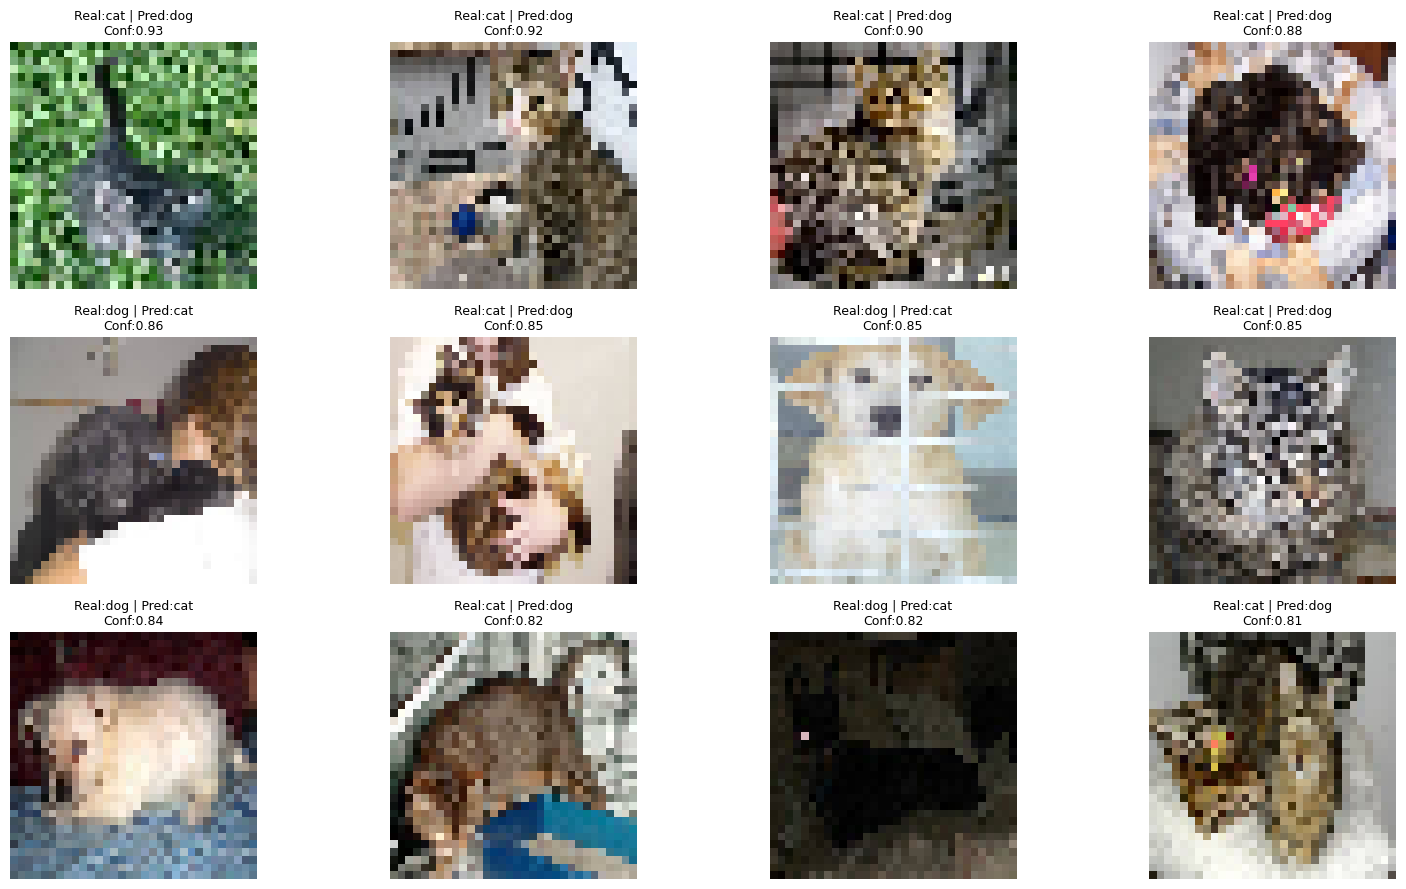

In [2]:
# Configuracion
IMG_SIZE = (32, 32)
BATCH_SIZE = 64
EPOCHS = 25
RANDOM_STATE = 42

base_dir = Path('data')
train_dirs = [
    base_dir / 'github_train_0',
    base_dir / 'github_train_1',
    base_dir / 'github_train_2',
    base_dir / 'github_train_3',
]
test_dir = base_dir / 'github_test'

label_map = {'cat': 0, 'dog': 1}
inv_label_map = {v: k for k, v in label_map.items()}


def extract_label(filepath: Path):
    prefix = filepath.name.split('.')[0].lower()
    return label_map.get(prefix)


def load_images_from_paths(paths, img_size=(32, 32)):
    X, y, names = [], [], []
    for p in paths:
        label = extract_label(p)
        if label is None:
            continue
        img = load_img(p, target_size=img_size)
        arr = img_to_array(img)
        X.append(arr)
        y.append(label)
        names.append(p.name)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32), np.array(names)


# 1) Construccion de datasets
train_files = []
for d in train_dirs:
    train_files.extend(sorted(d.glob('*.jpg')))

test_files = sorted(test_dir.glob('*.jpg'))

X_train_full, y_train_full, names_train_full = load_images_from_paths(train_files, IMG_SIZE)
X_test, y_test, names_test = load_images_from_paths(test_files, IMG_SIZE)

print(f'Train samples: {len(X_train_full)}')
print(f'Test samples: {len(X_test)}')
print('Distribucion train (cat, dog):', np.bincount(y_train_full))
print('Distribucion test  (cat, dog):', np.bincount(y_test))

# Train/valid split
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val, names_train, names_val = train_test_split(
    X_train_full,
    y_train_full,
    names_train_full,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train_full
)

# Escalado
X_train = X_train / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0

# 2) Red CNN (minimo dos bloques conv+pool)
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# 3) Entrenamiento con EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

# Curvas de aprendizaje
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history['loss'], label='train_loss')
ax[0].plot(history.history['val_loss'], label='val_loss')
ax[0].set_title('Loss')
ax[0].legend()

ax[1].plot(history.history['accuracy'], label='train_acc')
ax[1].plot(history.history['val_accuracy'], label='val_acc')
ax[1].set_title('Accuracy')
ax[1].legend()
plt.tight_layout()
plt.show()

# 4) Evaluacion final + metricas
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

y_prob = model.predict(X_test, verbose=0).ravel()      # probabilidad de clase dog (1)
y_pred = (y_prob >= 0.5).astype(int)

print()
print('Classification report')
print(classification_report(y_test, y_pred, target_names=['cat', 'dog']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['cat', 'dog'],
    yticklabels=['cat', 'dog']
)
plt.title('Matriz de confusion')
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

# 5) 10% de imagenes mal clasificadas por clase con mayor confianza equivocada
results = pd.DataFrame({
    'filename': names_test,
    'y_true': y_test,
    'y_pred': y_pred,
    'prob_dog': y_prob,
})

errors = results[results['y_true'] != results['y_pred']].copy()
errors['true_label'] = errors['y_true'].map(inv_label_map)
errors['pred_label'] = errors['y_pred'].map(inv_label_map)

# confianza de la clase erronea predicha
errors['wrong_confidence'] = np.where(
    errors['y_pred'] == 1,
    errors['prob_dog'],
    1 - errors['prob_dog']
)

selected_parts = []
for cls in [0, 1]:
    cls_errors = errors[errors['y_true'] == cls].copy()
    n_take = int(np.ceil(len(cls_errors) * 0.10))
    if len(cls_errors) > 0:
        n_take = max(1, n_take)
        top_cls = cls_errors.sort_values('wrong_confidence', ascending=False).head(n_take)
        selected_parts.append(top_cls)

selected_errors = pd.concat(selected_parts).sort_values('wrong_confidence', ascending=False) if selected_parts else pd.DataFrame()

print()
print('Errores por clase:')
print(errors['true_label'].value_counts())
print()
print('Seleccion final (top 10% por clase real):')
print(selected_errors[['filename', 'true_label', 'pred_label', 'wrong_confidence']].head(20))

# Visualizacion de una muestra seleccionada
if len(selected_errors) > 0:
    show_n = min(12, len(selected_errors))
    sample_df = selected_errors.head(show_n)

    ncols = 4
    nrows = int(np.ceil(show_n / ncols))
    plt.figure(figsize=(4 * ncols, 3 * nrows))

    for i, (_, row) in enumerate(sample_df.iterrows(), start=1):
        img_path = test_dir / row['filename']
        img = load_img(img_path, target_size=IMG_SIZE)
        plt.subplot(nrows, ncols, i)
        plt.imshow(img)
        plt.title(
            f"Real:{row['true_label']} | Pred:{row['pred_label']}\nConf:{row['wrong_confidence']:.2f}",
            fontsize=9
        )
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print('No hay errores de clasificacion para mostrar.')
